# Segmented TSP Multi-Vehicle Route Optimization for Plant Watering in Surabaya Timur (Genetic Algorithm)

**Goal:** Starting from one depot, assign park segments to multiple vehicles. Each vehicle fills water (8000 L capacity) at a water source, visits its assigned segments (consuming water per segment demand), refills when the tank runs out, and returns to the depot.

**Algorithm:** Genetic Algorithm (GA) with Edge Recombination Crossover (ERX) and Rank-Based Selection

**Key Features:**
- Segmented TSP: each park is a road segment (start + end point), not a single coordinate
- Multi-vehicle routing with demand-aware water capacity constraints (8000 L per fill)
- Automatic water refill trips when tank is insufficient for the next segment
- OSRM road-network distances (asymmetric matrix)
- Bearing-aware snapping for divided roads

In [10]:
%pip install requests folium numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from pathlib import Path
from functools import lru_cache

random.seed(42)
np.random.seed(42)

OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"
RETURN_TO_DEPOT = True

In [12]:
NUM_VEHICLES = 5
RETURN_TO_DEPOT = True
ASSIGNMENT_STRATEGY = 'round_robin'
WATER_CSV_PATH = "Dataset/water.csv"
WATER_ASSIGNMENT_STRATEGY = 'nearest'
TANK_CAPACITY = 8000

print(f"Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}")
print(f"Water source file : {WATER_CSV_PATH}")
print(f"Tank capacity     : {TANK_CAPACITY} liters")

Multi-vehicle mode: 5 vehicles, strategy=round_robin
Water source file : Dataset/water.csv
Tank capacity     : 8000 liters


## 1. Define Depot and Load Data from CSV

Each park is a **segment** with `start_lat`, `start_lon`, `end_lat`, `end_lon`, and a `demand` column (liters of water needed). Water sources are loaded from a separate CSV.

The parks CSV (`parks-demand.csv`) must contain the following columns:
- `start_lat`, `start_lon` — segment start coordinate
- `end_lat`, `end_lon` — segment end coordinate
- `demand` — liters of water required for this segment

Optional columns: `id`, `length (m)`, `width (m)`, `area (m2)`

In [13]:
DEPOT = (-7.278358153631059, 112.76325243881848)
CSV_PATH = "Dataset/parks-demand.csv"

REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]
df_segments = pd.read_csv(CSV_PATH)

for col in ["length (m)", "width (m)", "area (m2)", "demand"]:
    if col in df_segments.columns:
        df_segments[col] = (
            df_segments[col].astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "id" in row.index and pd.notna(row["id"]):
        return str(row["id"])
    return f"Segment {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    demand_val = float(row["demand"]) if "demand" in row.index and pd.notna(row["demand"]) else 0.0
    PLANTS.append({
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
        "demand":    demand_val,
    })

print(f"Loaded {len(PLANTS)} park segments from {CSV_PATH}")
display(df_segments.head(10))

WATER_REQUIRED_COLS = ["water_id", "lat", "lon"]
df_water = pd.read_csv(WATER_CSV_PATH)
missing_water_cols = [c for c in WATER_REQUIRED_COLS if c not in df_water.columns]
if missing_water_cols:
    raise ValueError(f"Water source CSV is missing columns: {missing_water_cols}")

WATER_SOURCES = []
for _, row in df_water.iterrows():
    WATER_SOURCES.append({
        "water_id": str(row["water_id"]).strip(),
        "lat":      float(row["lat"]),
        "lon":      float(str(row["lon"]).strip()),
    })

print(f"Loaded {len(WATER_SOURCES)} water source(s) from {WATER_CSV_PATH}")
display(df_water)

total_demand = sum(p["demand"] for p in PLANTS)
print(f"\nTotal demand across all segments: {total_demand:,.0f} liters")
print(f"Avg demand per segment: {total_demand / len(PLANTS):,.0f} liters")
print(f"Tank capacity: {TANK_CAPACITY} liters")
print(f"Min refills needed (fleet): {math.ceil(total_demand / TANK_CAPACITY)}")

Loaded 34 park segments from Dataset/parks-demand.csv


,id,start_lat,start_lon,end_lat,end_lon,length (m),width (m),area (m2),demand
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502,1250.0,4.0,5000.0,3750.0
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714,575.0,2.0,1150.0,862.5
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162,950.0,9.0,8550.0,6412.5
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482,2000.0,5.0,10000.0,7500.0
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143,660.0,9.0,5940.0,4455.0
5,Jalan Kertajaya,-7.278264,112.755534,-7.277394,112.750760,525.0,9.0,4725.0,3543.8
6,Jalan Doktor Insinyur Haji Soekarno,-7.250032,112.784244,-7.254943,112.782404,578.0,7.0,4046.0,3034.5
7,Jalan Kalijudan,-7.255050,112.782372,-7.263295,112.783069,935.0,7.0,6545.0,4908.8
8,Jalan Doktor Insinyur Haji Soekarno,-7.263567,112.783061,-7.269811,112.782163,700.0,4.5,3150.0,2362.5
9,Jalan Doktor Insinyur Haji Soekarno,-7.270306,112.782088,-7.280379,112.780881,1000.0,5.0,5000.0,3750.0


Loaded 9 water source(s) from Dataset/water.csv


,water_id,lat,lon
0,Selokan Depan Perumahan YKP Pandugo,-7.320818,112.789714
1,Selokan Depan Samator,-7.309816,112.773894
2,Selokan Dekat Pizza Hut Merr,-7.297944,112.782019
3,Selokan Dharmahusada Indah,-7.277584,112.772274
4,Sungai Depan ITATS,-7.289701,112.778826
5,Sungai Wisma Permai,-7.274711,112.793570
6,Selokan Dekat Resto Niki Sae,-7.272806,112.781376
7,Sungai Depan SPBU Manyar (Dekat RS Bedah),-7.280928,112.771908
8,Sungai Seberang Apartemen Gunawangsa Menur,-7.289537,112.768956



Total demand across all segments: 106,940 liters
Avg demand per segment: 3,145 liters
Tank capacity: 8000 liters
Min refills needed (fleet): 14


## 2. Prepare Unique Endpoints

Master list of coordinates: index 0 = depot, then each park contributes `a_idx` (start) and `b_idx` (end), and water sources are appended at the end.

OSRM's **table** service will give us pairwise road-network distances between all of these points.

In [14]:
POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])
    a_idx = len(POINTS); POINTS.append(a); POINT_LABELS.append(f'{p["name"]} A')
    b_idx = len(POINTS); POINTS.append(b); POINT_LABELS.append(f'{p["name"]} B')
    SEGMENTS.append({
        "seg_id": i - 1, "name": p["name"],
        "a_idx": a_idx, "b_idx": b_idx, "demand": p["demand"],
    })

WATER_SOURCE_INDICES = []
for ws in WATER_SOURCES:
    ws_idx = len(POINTS)
    POINTS.append((ws["lat"], ws["lon"]))
    POINT_LABELS.append(f'Water {ws["water_id"]}')
    WATER_SOURCE_INDICES.append(ws_idx)

print("Total table points:", len(POINTS))
print(f"  Depot         : 1")
print(f"  Park endpoints: {len(SEGMENTS) * 2}")
print(f"  Water sources : {len(WATER_SOURCES)}")
print()
print("First 5 segments (with demand):")
for s in SEGMENTS[:5]:
    print(f"  {s['name']}: a={s['a_idx']}, b={s['b_idx']}, demand={s['demand']:.0f} L")
print()
print("Water source indices:", list(zip(
    [ws['water_id'] for ws in WATER_SOURCES], WATER_SOURCE_INDICES)))

Total table points: 78
  Depot         : 1
  Park endpoints: 68
  Water sources : 9

First 5 segments (with demand):
  Jalan Kenjeran: a=1, b=2, demand=3750 L
  Jalan Raya Mulyosari: a=3, b=4, demand=862 L
  Jalan Raya Kertajaya Indah: a=5, b=6, demand=6412 L
  Jalan Raya Kertajaya Indah: a=7, b=8, demand=7500 L
  Jalan Kertajaya: a=9, b=10, demand=4455 L

Water source indices: [('Selokan Depan Perumahan YKP Pandugo', 69), ('Selokan Depan Samator', 70), ('Selokan Dekat Pizza Hut Merr', 71), ('Selokan Dharmahusada Indah', 72), ('Sungai Depan ITATS', 73), ('Sungai Wisma Permai', 74), ('Selokan Dekat Resto Niki Sae', 75), ('Sungai Depan SPBU Manyar (Dekat RS Bedah)', 76), ('Sungai Seberang Apartemen Gunawangsa Menur', 77)]


## 3. Snap Coordinates (Bearing-Aware)

Multi-layer snapping strategy for divided roads:
1. OSRM `/match` with bearing hint
2. OSRM `/match` without bearing (fallback)
3. `/nearest` with bearing scoring (last resort)

In [15]:
snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def osrm_nearest(pt, number=5, timeout=60):
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]
    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)
    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt, "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""), "nodes": wp.get("nodes", []), "raw": wp,
        })
    snap_cache[key] = out
    return out

def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=60;60&gaps=ignore&bearings={bear_hint};{bear_hint}")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=50;50&gaps=ignore")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    candidates = osrm_nearest(pt, number=number)
    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        s2i_bear = bearing_deg(snap, pt)
        rb1 = (s2i_bear + 90) % 360; rb2 = (s2i_bear - 90) % 360
        best_diff = min(angle_diff(rb1, seg_bearing), angle_diff(rb2, seg_bearing))
        scored.append((best_diff, c["distance_to_road_m"], c))
    scored.sort(key=lambda x: (x[0], x[1]))
    bd, _, bc = scored[0]
    if bd <= tolerance_deg:
        return bc, f"nearest-bearing(diff={bd:.0f}deg)"
    else:
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={bd:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    n = len(points)
    snapped = [None] * n
    infos = [None] * n
    seg_indices = set()
    for seg in segments:
        seg_indices.add(seg["a_idx"]); seg_indices.add(seg["b_idx"])

    for i in range(n):
        if i in seg_indices: continue
        cands = osrm_nearest(points[i], number=1); ch = cands[0]
        snapped[i] = ch["snapped_latlon"]
        infos[i] = {"index": i, "raw_latlon": points[i], "snapped_latlon": ch["snapped_latlon"],
                     "distance_to_road_m": ch["distance_to_road_m"], "road_name": ch["name"],
                     "method": "nearest", "bearing_deg": None}
        if verbose:
            print(f"[{i:>3}] NON-SEG -> snap={ch['snapped_latlon']} | offset={ch['distance_to_road_m']:.1f}m")
        if sleep_sec > 0: time.sleep(sleep_sec)

    for seg in segments:
        a_idx, b_idx = seg["a_idx"], seg["b_idx"]
        pt_a, pt_b = points[a_idx], points[b_idx]
        name = seg["name"]
        seg_bear = bearing_deg(pt_a, pt_b)
        method = None; snap_a = snap_b = None

        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0: time.sleep(sleep_sec)
        if result is not None:
            snap_a, snap_b = result
            sb = bearing_deg(snap_a, snap_b)
            if angle_diff(sb, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                opp = (seg_bear + 180) % 360
                r2 = osrm_match_bearing(pt_a, pt_b, opp)
                if sleep_sec > 0: time.sleep(sleep_sec)
                if r2 is not None:
                    sb2 = bearing_deg(r2[0], r2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(sb, seg_bear):
                        snap_a, snap_b = r2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0: time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result; method = "match-no-bearing"

        if method is None:
            ca, la = nearest_best_bearing(pt_a, seg_bear)
            cb, lb = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0: time.sleep(sleep_sec * 2)
            snap_a, snap_b = ca["snapped_latlon"], cb["snapped_latlon"]
            method = "nearest-bearing-fallback"

        snapped[a_idx] = snap_a; snapped[b_idx] = snap_b
        oa, ob = haversine_m(pt_a, snap_a), haversine_m(pt_b, snap_b)
        for idx, pt, snap, offset in [(a_idx, pt_a, snap_a, oa), (b_idx, pt_b, snap_b, ob)]:
            infos[idx] = {"index": idx, "raw_latlon": pt, "snapped_latlon": snap,
                          "distance_to_road_m": offset, "road_name": name,
                          "method": method, "bearing_deg": seg_bear}
        if verbose:
            sb = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            ok = "OK" if angle_diff(sb, seg_bear) <= 90 else "WARN"
            print(f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                  f"bear={seg_bear:.0f}->{sb:.0f} [{ok}] | A={oa:.0f}m B={ob:.0f}m")

    return snapped, infos


SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(POINTS, SEGMENTS, verbose=True, sleep_sec=0.05)

snap_df = pd.DataFrame([{
    "idx": info["index"], "label": POINT_LABELS[info["index"]],
    "snap_lat": info["snapped_latlon"][0], "snap_lon": info["snapped_latlon"][1],
    "offset_m": info["distance_to_road_m"], "method": info["method"],
} for info in SNAP_INFOS])
display(snap_df.head(20))
print(f"Max snap offset: {snap_df['offset_m'].max():.1f} m")
print(f"Mean snap offset: {snap_df['offset_m'].mean():.1f} m")
print(snap_df["method"].value_counts())

[  0] NON-SEG -> snap=(-7.277913, 112.763309) | offset=49.6m
[ 69] NON-SEG -> snap=(-7.320826, 112.789715) | offset=0.9m
[ 70] NON-SEG -> snap=(-7.309877, 112.773878) | offset=7.0m
[ 71] NON-SEG -> snap=(-7.297944, 112.782037) | offset=2.0m
[ 72] NON-SEG -> snap=(-7.277714, 112.772264) | offset=14.4m
[ 73] NON-SEG -> snap=(-7.289793, 112.778828) | offset=10.2m
[ 74] NON-SEG -> snap=(-7.274728, 112.793573) | offset=1.9m
[ 75] NON-SEG -> snap=(-7.272815, 112.781375) | offset=1.0m
[ 76] NON-SEG -> snap=(-7.280974, 112.771902) | offset=5.1m
[ 77] NON-SEG -> snap=(-7.289442, 112.768994) | offset=11.3m
[  1/2  ] nearest-bearing-fallback                 | Jalan Kenjeran               | bear=286->286 [OK] | A=12m B=11m
[  3/4  ] nearest-bearing-fallback                 | Jalan Raya Mulyosari         | bear=172->172 [OK] | A=7m B=7m
[  5/6  ] nearest-bearing-fallback                 | Jalan Raya Kertajaya Indah   | bear=262->261 [OK] | A=9m B=12m
[  7/8  ] nearest-bearing-fallback              

,idx,label,snap_lat,snap_lon,offset_m,method
0,0,Depot,-7.277913,112.763309,49.614380,nearest
1,1,Jalan Kenjeran A,-7.252987,112.795263,11.582105,nearest-bearing-fallback
2,2,Jalan Kenjeran B,-7.249951,112.784476,11.474870,nearest-bearing-fallback
3,3,Jalan Raya Mulyosari A,-7.258298,112.795552,7.137640,nearest-bearing-fallback
4,4,Jalan Raya Mulyosari B,-7.273638,112.797777,7.296273,nearest-bearing-fallback
5,5,Jalan Raya Kertajaya Indah A,-7.279325,112.789607,9.340444,nearest-bearing-fallback
6,6,Jalan Raya Kertajaya Indah B,-7.280671,112.781176,12.415691,nearest-bearing-fallback
7,7,Jalan Raya Kertajaya Indah A,-7.280519,112.780695,10.199266,nearest-bearing-fallback
8,8,Jalan Raya Kertajaya Indah B,-7.279494,112.762465,11.747513,nearest-bearing-fallback
9,9,Jalan Kertajaya A,-7.279432,112.762099,8.083129,nearest-bearing-fallback


Max snap offset: 49.6 m
Mean snap offset: 8.0 m
method
nearest-bearing-fallback    68
nearest                     10
Name: count, dtype: int64


## 4. Query OSRM Table (Road Distances in Meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`. OSRM may produce asymmetric distances because of one-way roads.

In [16]:
def ll_to_osrm(pt):
    return f"{pt[1]:.6f},{pt[0]:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        yield list(range(start, min(start + batch_size, n)))

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = (f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations=distance"
           f"&sources={';'.join(str(i) for i in source_idx)}"
           f"&destinations={';'.join(str(i) for i in dest_idx)}")
    r = requests.get(url, timeout=timeout); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    distances = data.get("distances")
    if distances is None: raise RuntimeError("No distances in response")
    D = np.array([[np.inf if v is None else float(v) for v in row] for row in distances], dtype=float)
    if sleep_sec > 0: time.sleep(sleep_sec)
    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)
    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))
    total = len(row_batches) * len(col_batches)
    req = 0
    for rows in row_batches:
        for cols in col_batches:
            req += 1
            if verbose:
                print(f"Request {req}/{total} | rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}")
            subD, _ = osrm_table_submatrix(points, rows, cols, timeout, sleep_sec)
            full[np.ix_(rows, cols)] = subD
    return full

dist_matrix = osrm_table_batched(SNAPPED_POINTS, batch_size=25, timeout=120, sleep_sec=0.1, verbose=True)
print("Distance matrix shape:", dist_matrix.shape)
print("Sample (first 5x5):")
print(np.round(dist_matrix[:5, :5], 0))

Request 1/16 | rows 0-24 | cols 0-24
Request 2/16 | rows 0-24 | cols 25-49
Request 3/16 | rows 0-24 | cols 50-74
Request 4/16 | rows 0-24 | cols 75-77
Request 5/16 | rows 25-49 | cols 0-24
Request 6/16 | rows 25-49 | cols 25-49
Request 7/16 | rows 25-49 | cols 50-74
Request 8/16 | rows 25-49 | cols 75-77
Request 9/16 | rows 50-74 | cols 0-24
Request 10/16 | rows 50-74 | cols 25-49
Request 11/16 | rows 50-74 | cols 50-74
Request 12/16 | rows 50-74 | cols 75-77
Request 13/16 | rows 75-77 | cols 0-24
Request 14/16 | rows 75-77 | cols 25-49
Request 15/16 | rows 75-77 | cols 50-74
Request 16/16 | rows 75-77 | cols 75-77
Distance matrix shape: (78, 78)
Sample (first 5x5):
[[   0. 6952. 5996. 6336. 4985.]
 [7135.    0. 1238. 1162. 2620.]
 [6171. 1372.    0. 2226. 3684.]
 [5883.  616. 1854.    0. 1767.]
 [4904. 2642. 3880. 2027.    0.]]


## 5. Cost of a Fixed Segment Order (Orientation DP)

For each segment, 2 traversal directions exist:
- orientation `0`: A → B
- orientation `1`: B → A

Dynamic programming selects the best orientation sequence for a given visit order.

In [17]:
DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True, water_source_idx=None):
    if len(order) == 0: return 0.0, [], []
    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]
    dp, parent = [], []

    fc = [0.0, 0.0]
    if water_source_idx is not None:
        fc[0] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, b0] + D[b0, a0]
    else:
        fc[0] = D[DEPOT_IDX, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, b0] + D[b0, a0]
    dp.append(fc); parent.append([-1, -1])

    for pos in range(1, len(order)):
        ps, cs = segments[order[pos-1]], segments[order[pos]]
        pe = [ps["b_idx"], ps["a_idx"]]
        ce = [cs["a_idx"], cs["b_idx"]]
        li = [D[cs["a_idx"], cs["b_idx"]], D[cs["b_idx"], cs["a_idx"]]]
        cd, cp = [np.inf, np.inf], [-1, -1]
        for co in [0, 1]:
            bv, bp = np.inf, -1
            for po in [0, 1]:
                c = dp[pos-1][po] + D[pe[po], ce[co]] + li[co]
                if c < bv: bv, bp = c, po
            cd[co], cp[co] = bv, bp
        dp.append(cd); parent.append(cp)

    ls = segments[order[-1]]
    le = [ls["b_idx"], ls["a_idx"]]
    fc2 = dp[-1][:]
    if return_to_depot:
        fc2 = [dp[-1][0] + D[le[0], DEPOT_IDX], dp[-1][1] + D[le[1], DEPOT_IDX]]

    blo = int(np.argmin(fc2)); bc = float(fc2[blo])
    oris = [None] * len(order); oris[-1] = blo
    for pos in range(len(order)-1, 0, -1):
        oris[pos-1] = parent[pos][oris[pos]]
    return bc, oris, dp

so = list(range(len(SEGMENTS)))
sc, _, _ = evaluate_order(so, dist_matrix, SEGMENTS, RETURN_TO_DEPOT,
                          water_source_idx=WATER_SOURCE_INDICES[0] if WATER_SOURCE_INDICES else None)
print(f"Sample sequential order cost = {sc:,.0f} m")

Sample sequential order cost = 123,820 m


## 6. Genetic Algorithm (GA)

### Conceptual Overview

Genetic Algorithm (GA) is a metaheuristic inspired by the process of natural selection. A **population** of candidate solutions (route orderings) evolves over generations through selection, crossover, and mutation operations. Solutions that minimize total route distance are more likely to survive and produce offspring, gradually steering the population toward near-optimal solutions.

### Mathematical Formulation

Each individual in the population is a **permutation** $\pi = (\pi_1, \pi_2, \ldots, \pi_n)$ representing the visit order of $n$ segments.

**Fitness function** — total route distance including depot→water, water→first segment, segment traversals, inter-segment travel, and optional return to depot:

$$f(\pi) = d(\text{depot}, w) + \sum_{k=1}^{n} \bigl[d(\text{exit}_{k-1}, \text{entry}_k) + d(\text{entry}_k, \text{exit}_k)\bigr] + d(\text{exit}_n, \text{depot})$$

where traversal direction (A→B or B→A) is chosen optimally per segment via dynamic programming.

**Rank-based selection** — individuals are sorted by fitness (best → worst) and assigned selection probabilities based on rank (linear ranking). Parents are sampled from this rank-weighted distribution.

**Edge Recombination Crossover (ERX)** — preserves adjacency by building an edge map from both parents and constructing a child by choosing the next node using shared edges and smallest adjacency lists.

**Insertion mutation** — with probability $p_m$ per gene, one element is removed and inserted at another random position, preserving permutation validity.

### Adaptation for Segmented TSP with Water Demand

1. Each "city" is a **segment** (pair of endpoints), traversable in either direction.
2. After GA constructs a route ordering, `evaluate_order` uses DP to find the optimal traversal direction for each segment.
3. The `simulate_route_with_refills` function computes the **true total distance** including detours to water sources whenever the tank runs dry — this is the value the GA optimizes.
4. Ants (solutions) that minimize the true distance with refills are selected for reproduction.

### Parameters
| Parameter | Description |
|-----------|-------------|
| `pop_size` | Number of individuals per generation |
| `generations` | Total number of generations |
| `mut_rate` | Probability of insertion mutation per gene |
| `crossover_rate` | Probability of applying ERX crossover |
| `rank_based_k` | Selection pressure for rank-based selection |

In [18]:
def find_nearest_water_source(current_exit_idx, D, water_source_indices):
    best_ws, best_dist = None, np.inf
    for ws_idx in water_source_indices:
        d = D[current_exit_idx, ws_idx]
        if d < best_dist:
            best_dist, best_ws = d, ws_idx
    return best_ws, best_dist

def simulate_route_with_refills(order, orientations, segments, D,
                                water_source_indices, initial_ws_idx,
                                tank_capacity=8000, return_to_depot=True):
    plan = []
    total_dist = 0.0
    water = 0
    cur_idx = DEPOT_IDX
    refill_count = 0

    if initial_ws_idx is not None:
        ld = D[cur_idx, initial_ws_idx]; total_dist += ld
        plan.append({'type': 'drive_to_water', 'from_idx': cur_idx, 'to_idx': initial_ws_idx,
            'distance_m': ld, 'water_before': water, 'water_after': tank_capacity,
            'label': f"Depot -> {POINT_LABELS[initial_ws_idx]} (initial fill)"})
        cur_idx = initial_ws_idx; water = tank_capacity; refill_count = 1

    for step, (si, ori) in enumerate(zip(order, orientations)):
        seg = segments[si]; demand = seg.get("demand", 0)
        entry = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_ = seg["b_idx"] if ori == 0 else seg["a_idx"]

        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            total_dist += wd
            plan.append({'type': 'drive_to_water', 'from_idx': cur_idx, 'to_idx': ws,
                'distance_m': wd, 'water_before': water, 'water_after': tank_capacity,
                'label': f"Refill at {POINT_LABELS[ws]} (water={water:.0f}L < demand={demand:.0f}L)"})
            cur_idx = ws; water = tank_capacity; refill_count += 1

        ld = D[cur_idx, entry]; total_dist += ld
        plan.append({'type': 'drive_to_segment', 'from_idx': cur_idx, 'to_idx': entry,
            'distance_m': ld, 'water_before': water, 'label': f"Drive to {seg['name']} entry"})
        cur_idx = entry

        sd = D[entry, exit_]; total_dist += sd; water -= demand
        plan.append({'type': 'traverse_segment', 'from_idx': entry, 'to_idx': exit_,
            'segment_name': seg['name'], 'segment_idx': si, 'distance_m': sd,
            'demand': demand, 'water_before': water + demand, 'water_after': water,
            'label': f"Water {seg['name']} (demand={demand:.0f}L, remaining={water:.0f}L)"})
        cur_idx = exit_

    if return_to_depot:
        ld = D[cur_idx, DEPOT_IDX]; total_dist += ld
        plan.append({'type': 'return_to_depot', 'from_idx': cur_idx, 'to_idx': DEPOT_IDX,
            'distance_m': ld, 'water_before': water, 'label': 'Return to depot'})
    return plan, total_dist, refill_count


def init_population(pop_size, n_segments):
    base = list(range(n_segments))
    return [random.sample(base, len(base)) for _ in range(pop_size)]

def rank_based(pop, fits, selection_pressure=3, k=None):
    n = len(pop)
    if n == 0:
        return []

    if k is not None:
        selection_pressure = k
    ranked_indices = sorted(range(n), key=lambda i: (fits[i], i))
    s = 1.0 + min(max(selection_pressure, 1), n - 1) / max(1, n - 1)

    selection_probs = []
    for rank_pos, _ in enumerate(ranked_indices):
        reverse_rank = n - rank_pos
        if n == 1:
            p = 1.0
        else:
            p = (2 - s) / n + (2 * (reverse_rank - 1) * (s - 1)) / (n * (n - 1))
        selection_probs.append(p)

    total_prob = sum(selection_probs)
    if total_prob <= 0:
        selection_probs = [1.0 / n] * n
    else:
        selection_probs = [p / total_prob for p in selection_probs]

    pick = random.random()
    cumulative_prob = 0.0
    for idx, p in zip(ranked_indices, selection_probs):
        cumulative_prob += p
        if pick <= cumulative_prob:
            return pop[idx][:]
    return pop[ranked_indices[-1]][:]

def erx_crossover(p1, p2, D=None):
    size = len(p1)
    if size <= 2:
        return p1[:]

    adjacency_map = {gene: set() for gene in p1}
    edge_frequency = {}

    def register_edge(node_a, node_b):
        if node_a == node_b:
            return
        adjacency_map[node_a].add(node_b)
        adjacency_map[node_b].add(node_a)
        key = tuple(sorted((node_a, node_b)))
        edge_frequency[key] = edge_frequency.get(key, 0) + 1

    for parent in (p1, p2):
        for i in range(size):
            node = parent[i]
            left = parent[(i - 1) % size]
            right = parent[(i + 1) % size]
            register_edge(node, left)
            register_edge(node, right)

    remaining = set(p1)
    current_node = random.choice(p1)
    offspring = []

    while remaining:
        offspring.append(current_node)
        remaining.remove(current_node)

        candidate_nodes = [n for n in adjacency_map.get(current_node, set()) if n in remaining]

        for node in list(adjacency_map.keys()):
            adjacency_map[node].discard(current_node)
        adjacency_map.pop(current_node, None)

        if candidate_nodes:
            common_edge_nodes = [
                n for n in candidate_nodes
                if edge_frequency.get(tuple(sorted((current_node, n))), 0) >= 2
            ]
            pool = common_edge_nodes if common_edge_nodes else candidate_nodes

            min_degree = min(len(adjacency_map.get(n, set()) & remaining) for n in pool)
            best_candidates = [
                n for n in pool
                if len(adjacency_map.get(n, set()) & remaining) == min_degree
            ]

            if len(best_candidates) > 1:
                max_freq = max(edge_frequency.get(tuple(sorted((current_node, n))), 0) for n in best_candidates)
                best_candidates = [
                    n for n in best_candidates
                    if edge_frequency.get(tuple(sorted((current_node, n))), 0) == max_freq
                ]

            if D is not None and len(best_candidates) > 1:
                finite_candidates = [n for n in best_candidates if np.isfinite(D[current_node, n])]
                if finite_candidates:
                    min_dist = min(D[current_node, n] for n in finite_candidates)
                    best_candidates = [n for n in finite_candidates if D[current_node, n] == min_dist]

            next_node = random.choice(best_candidates)
        else:
            next_node = random.choice(list(remaining)) if remaining else None

        if next_node is None:
            break
        current_node = next_node

    if len(offspring) < size:
        leftovers = list(remaining)
        random.shuffle(leftovers)
        offspring.extend(leftovers)

    return offspring

def insertion_mutation(individual, rate=0.04):
    individual = individual[:]
    n = len(individual)
    if n < 2:
        return individual

    if random.random() >= rate:
        return individual

    from_idx = random.randrange(n)
    to_idx = random.randrange(n)
    if to_idx == from_idx:
        return individual

    moved_gene = individual.pop(from_idx)
    if to_idx > from_idx:
        to_idx -= 1
    individual.insert(to_idx, moved_gene)
    return individual


def genetic_algorithm_pure(
    D, segments,
    pop_size=80, generations=180,
    mut_rate=0.04, crossover_rate=0.9, rank_based_k=3,
    return_to_depot=True, water_source_idx=None,
    verbose_prefix="",
):
    n = len(segments)
    if n == 0:
        return [], [], 0.0, None
    if n == 1:
        cost, oris, _ = evaluate_order([0], D, segments, return_to_depot, water_source_idx)
        _, true_cost, _ = simulate_route_with_refills(
            [0], oris, segments, D, WATER_SOURCE_INDICES, water_source_idx, TANK_CAPACITY, return_to_depot)
        return [0], oris, float(true_cost), {
            "best_in_population": [float(true_cost)],
            "best_so_far": [float(true_cost)],
        }

    pop = init_population(pop_size, n)
    best_order, best_cost, best_oris = None, np.inf, None
    hist_pop, hist_best = [], []

    for gen in range(generations):
        fits = []
        for ind in pop:
            _, oris, _ = evaluate_order(ind, D, segments, return_to_depot, water_source_idx)
            _, true_cost, _ = simulate_route_with_refills(
                ind, oris, segments, D, WATER_SOURCE_INDICES, water_source_idx, TANK_CAPACITY, return_to_depot)
            fits.append(float(true_cost))

        gen_best_idx   = int(np.argmin(fits))
        gen_best_cost  = float(fits[gen_best_idx])
        gen_best_order = pop[gen_best_idx][:]

        if gen_best_cost < best_cost:
            best_cost  = gen_best_cost
            best_order = gen_best_order[:]
            _, best_oris, _ = evaluate_order(best_order, D, segments, return_to_depot, water_source_idx)

        hist_pop.append(gen_best_cost)
        hist_best.append(float(best_cost))

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = rank_based(pop, fits, k=rank_based_k)
            p2 = rank_based(pop, fits, k=rank_based_k)
            if random.random() < crossover_rate:
                child1 = erx_crossover(p1, p2)
                child2 = erx_crossover(p2, p1)
            else:
                child1, child2 = p1[:], p2[:]
            child1 = insertion_mutation(child1, rate=mut_rate)
            child2 = insertion_mutation(child2, rate=mut_rate)
            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)
        pop = new_pop

        if gen % 20 == 0:
            print(
                f"{verbose_prefix}Gen {gen:4d} | "
                f"best_pop_with_refills={gen_best_cost:,.0f} m | "
                f"best_so_far_with_refills={best_cost:,.0f} m"
            )

    history = {
        "best_in_population": hist_pop,
        "best_so_far":        hist_best,
    }
    return best_order, best_oris, float(best_cost), history


print("GA functions defined successfully.")


GA functions defined successfully.


## 7. Partition Segments Across Vehicles and Assign Water Sources

Segments are distributed among vehicles using `round_robin` or `block` strategy. Each vehicle is assigned the nearest water source to its segment centroid.

In [ ]:
def partition_segments(segments, num_vehicles, strategy='round_robin'):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))
    assignment = [[] for _ in range(num_vehicles)]
    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:  # block
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size
    return assignment

def assign_water_sources(vehicle_assignments, segments, points,
                         water_source_indices, water_sources, strategy='nearest'):
    n_ws = len(water_source_indices)
    result = []
    for v_idx, seg_ids in enumerate(vehicle_assignments):
        if n_ws == 1 or not seg_ids:
            result.append(water_source_indices[0] if water_source_indices else None)
            continue
        if strategy == 'round_robin':
            result.append(water_source_indices[v_idx % n_ws])
        else:  # nearest
            lats, lons = [], []
            for si in seg_ids:
                seg = segments[si]
                lats += [points[seg['a_idx']][0], points[seg['b_idx']][0]]
                lons += [points[seg['a_idx']][1], points[seg['b_idx']][1]]
            centroid = (sum(lats)/len(lats), sum(lons)/len(lons))
            best = min(range(n_ws), key=lambda i: haversine_m(centroid, points[water_source_indices[i]]))
            result.append(water_source_indices[best])
    return result


vehicle_assignments = partition_segments(SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY)
vehicle_water_indices = assign_water_sources(
    vehicle_assignments, SEGMENTS, SNAPPED_POINTS,
    WATER_SOURCE_INDICES, WATER_SOURCES, strategy=WATER_ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else "None"
    td = sum(SEGMENTS[i]['demand'] for i in seg_ids)
    rf = math.ceil(td / TANK_CAPACITY) if td > 0 else 0
    print(f"Vehicle {v+1:2d}: {len(seg_ids)} segs | demand={td:,.0f}L | refills~{rf} | water={ws_label}")
    for si in seg_ids:
        print(f"           - {SEGMENTS[si]['name']} ({SEGMENTS[si]['demand']:.0f}L)")

Total segments : 34
Vehicles used  : 5 / 5

Vehicle  1: 7 segs | demand=20,340L | refills~3 | water=Water Sungai Depan SPBU Manyar (Dekat RS Bedah)
           - Jalan Kenjeran (3750L)
           - Jalan Kertajaya (3544L)
           - Jalan Doktor Insinyur Haji Soekarno (2610L)
           - Jalan Arief Rahman Hakim (6142L)
           - Jalan Raya Menur (1744L)
           - Jalan Dharma Husada Indah II (1500L)
           - Jalan Semolowaru (1050L)
Vehicle  2: 7 segs | demand=15,563L | refills~2 | water=Water Selokan Dekat Resto Niki Sae
           - Jalan Raya Mulyosari (862L)
           - Jalan Doktor Insinyur Haji Soekarno (3034L)
           - Jalan Arief Rahman Hakim (1429L)
           - Jalan Dharmahusada Permai (2205L)
           - Jalan Dharmahusada Indah III (1069L)
           - Jalan Dharmahusada Indah III (1031L)
           - Jalan Kedung Baruk (5932L)
Vehicle  3: 7 segs | demand=22,410L | refills~3 | water=Water Selokan Dekat Resto Niki Sae
           - Jalan Raya Kertajaya Ind

## 8. Run GA for Every Vehicle

In [20]:
GA_PARAMS = dict(
    pop_size       = 80,
    generations    = 180,
    mut_rate       = 0.04,
    crossover_rate = 0.9,
    rank_based_k   = 3,
)

vehicle_results = []
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else 'None'
    if not seg_ids:
        print(f"Vehicle {v+1}: no segments assigned, skipping.")
        vehicle_results.append({'vehicle_id': v+1, 'seg_ids': [], 'local_segments': [],
            'best_order': [], 'orientations': [], 'total_dist_m': 0.0,
            'history': None, 'water_source_idx': ws_idx, 'water_label': ws_label})
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments  |  water={ws_label}")
    print(f"{'='*60}")
    local_segments = [SEGMENTS[i] for i in seg_ids]
    lo, loris, lc, lh = genetic_algorithm_pure(
        dist_matrix, local_segments, return_to_depot=RETURN_TO_DEPOT,
        water_source_idx=ws_idx, verbose_prefix=f"[V{v+1}] ", **GA_PARAMS)
    go = [seg_ids[i] for i in lo]
    vehicle_results.append({'vehicle_id': v+1, 'seg_ids': seg_ids, 'local_segments': local_segments,
        'best_order': go, 'local_order': lo, 'orientations': loris,
        'total_dist_m': lc, 'history': lh, 'water_source_idx': ws_idx, 'water_label': ws_label})
    print(f"Vehicle {v+1} best distance (with refills): {lc:,.0f} m ({lc/1000:.2f} km)")

print(f"\n{'='*60}")
print("FLEET SUMMARY (route distance with refill detours)")
print(f"{'='*60}")
tfd = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segs | "
              f"{r['total_dist_m']:>10,.0f} m ({r['total_dist_m']/1000:.2f} km)  water={r['water_label']}")
print(f"  Fleet total : {tfd:>10,.0f} m ({tfd/1000:.2f} km)")


Vehicle 1 / 5  --  7 segments  |  water=Water Sungai Depan SPBU Manyar (Dekat RS Bedah)
[V1] Gen    0 | best_pop_with_refills=32,538 m | best_so_far_with_refills=32,538 m
[V1] Gen   20 | best_pop_with_refills=34,245 m | best_so_far_with_refills=30,207 m
[V1] Gen   40 | best_pop_with_refills=33,779 m | best_so_far_with_refills=28,413 m
[V1] Gen   60 | best_pop_with_refills=30,209 m | best_so_far_with_refills=28,413 m
[V1] Gen   80 | best_pop_with_refills=32,019 m | best_so_far_with_refills=28,413 m
[V1] Gen  100 | best_pop_with_refills=31,869 m | best_so_far_with_refills=28,413 m
[V1] Gen  120 | best_pop_with_refills=32,103 m | best_so_far_with_refills=28,413 m
[V1] Gen  140 | best_pop_with_refills=29,566 m | best_so_far_with_refills=28,413 m
[V1] Gen  160 | best_pop_with_refills=31,552 m | best_so_far_with_refills=28,413 m
Vehicle 1 best distance (with refills): 28,413 m (28.41 km)

Vehicle 2 / 5  --  7 segments  |  water=Water Selokan Dekat Resto Niki Sae
[V2] Gen    0 | best_pop_wit

## 8.5 GA Convergence Plots (Per Vehicle)

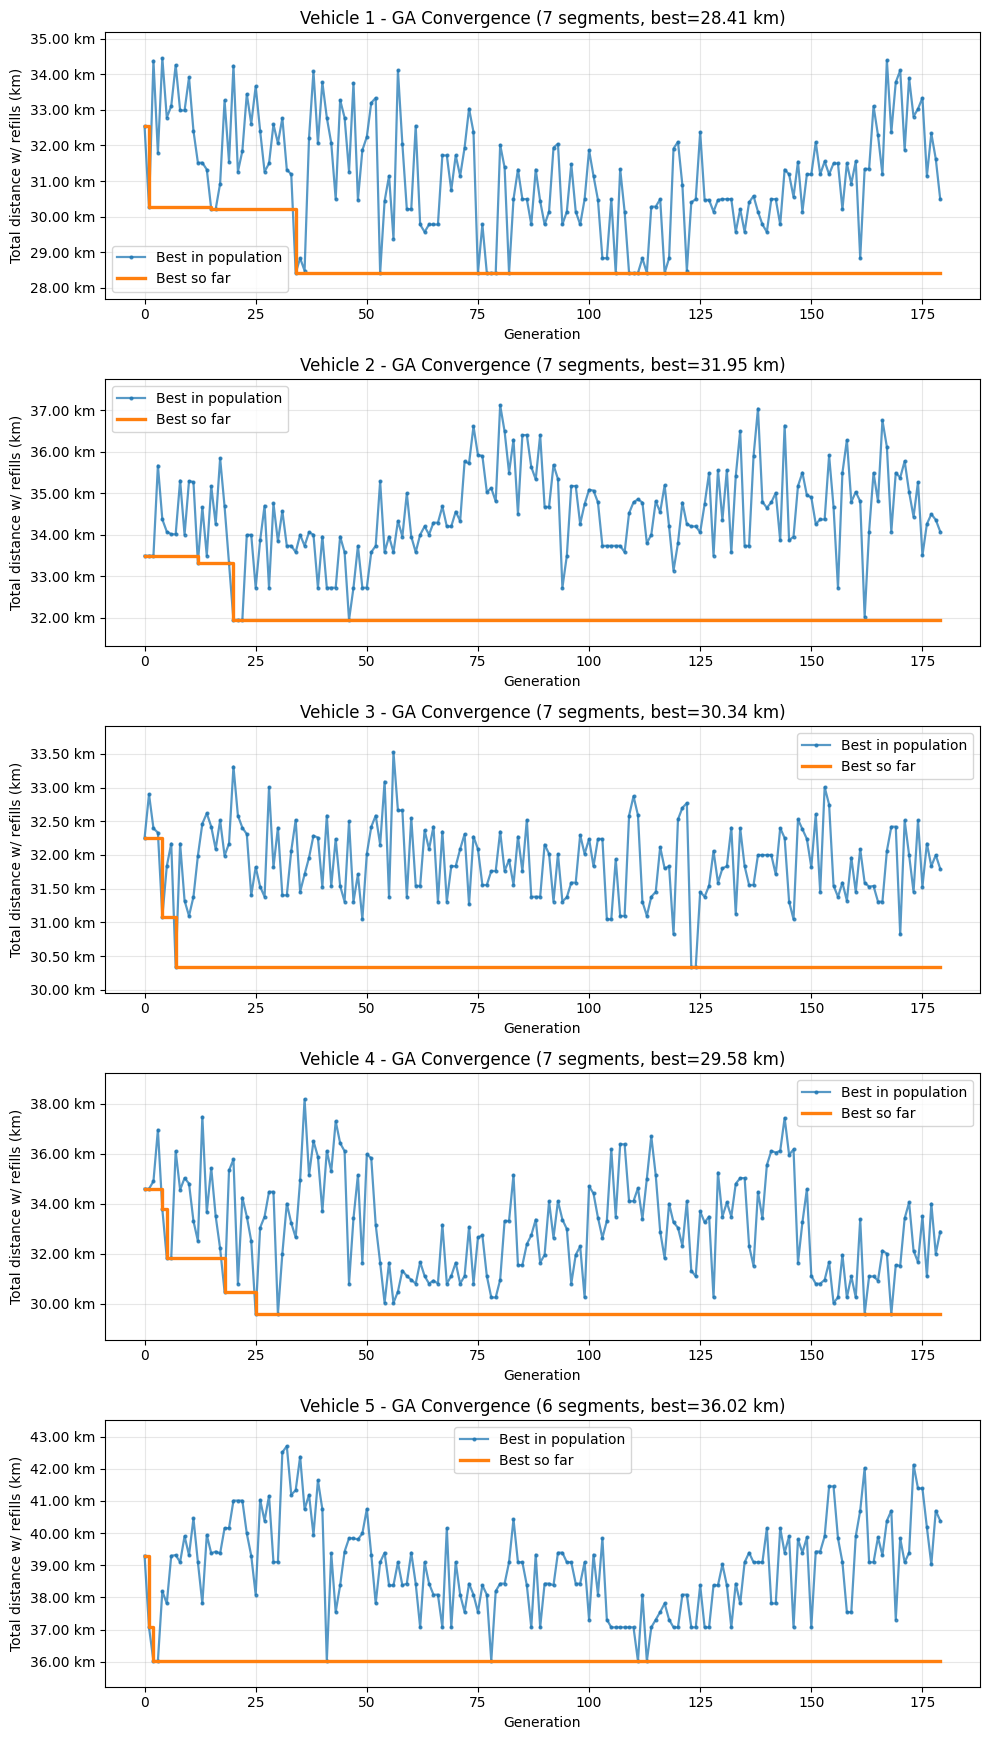

In [21]:
active_results = [r for r in vehicle_results if r.get('history')]

if not active_results:
    print("No GA history available to plot.")
else:
    fig, axes = plt.subplots(
        nrows=len(active_results),
        ncols=1,
        figsize=(10, 3.5 * len(active_results)),
        squeeze=False,
    )

    for pi, r in enumerate(active_results):
        ax = axes[pi, 0]
        h = r['history']

        pop_hist  = h.get('best_in_population', [])
        best_hist = h.get('best_so_far', [])
        iters = list(range(len(best_hist)))

        pop_km  = [v / 1000 for v in pop_hist]
        best_km = [v / 1000 for v in best_hist]

        ax.plot(iters, pop_km,  label='Best in population', alpha=0.75, linewidth=1.6, marker='o', markersize=2)
        ax.plot(iters, best_km, label='Best so far', linewidth=2.4, drawstyle='steps-post')

        finite_vals = [v for v in pop_km + best_km if np.isfinite(v)]
        if finite_vals:
            ymin, ymax = min(finite_vals), max(finite_vals)
            if np.isclose(ymin, ymax):
                pad = max(abs(ymin) * 0.02, 0.1)
            else:
                pad = (ymax - ymin) * 0.12
            ax.set_ylim(ymin - pad, ymax + pad)

        final_best = best_km[-1] if best_km else np.nan
        ax.set_title(
            f"Vehicle {r['vehicle_id']} - GA Convergence "
            f"({len(r['seg_ids'])} segments, best={final_best:,.2f} km)"
        )
        ax.set_xlabel("Generation")
        ax.set_ylabel("Total distance w/ refills (km)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.2f} km'))

    plt.tight_layout()
    plt.show()



## 9. Inspect Chosen Traversal Directions

In [22]:
def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (si, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[si]
        rows.append({"Step": step, "Segment": seg["name"],
            "Direction": "A->B" if ori == 0 else "B->A",
            "Demand (L)": seg.get("demand", 0)})
    return pd.DataFrame(rows)

for r in vehicle_results:
    if not r['seg_ids']: continue
    print(f"\nVehicle {r['vehicle_id']} route:")
    display(segment_orientation_summary(r['best_order'], r['orientations'], SEGMENTS))


Vehicle 1 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Kertajaya,A->B,3543.8
1,2,Jalan Raya Menur,A->B,1743.8
2,3,Jalan Arief Rahman Hakim,B->A,6142.5
3,4,Jalan Semolowaru,B->A,1050.0
4,5,Jalan Doktor Insinyur Haji Soekarno,B->A,2610.0
5,6,Jalan Dharma Husada Indah II,B->A,1500.0
6,7,Jalan Kenjeran,A->B,3750.0



Vehicle 2 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Dharmahusada Indah III,B->A,1031.3
1,2,Jalan Dharmahusada Indah III,A->B,1068.8
2,3,Jalan Doktor Insinyur Haji Soekarno,B->A,3034.5
3,4,Jalan Raya Mulyosari,A->B,862.5
4,5,Jalan Dharmahusada Permai,A->B,2205.0
5,6,Jalan Arief Rahman Hakim,A->B,1428.8
6,7,Jalan Kedung Baruk,A->B,5932.5



Vehicle 3 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Dharmahusada Indah I,B->A,1500.0
1,2,Jalan Dharma Husada Indah II,B->A,1230.0
2,3,Jalan Dharmahusada Indah Utara XIV,B->A,1518.8
3,4,Jalan Kalijudan,B->A,4908.8
4,5,Jalan Doktor Insinyur Haji Soekarno,B->A,3750.0
5,6,Jalan Raya ITS,A->B,3090.0
6,7,Jalan Raya Kertajaya Indah,A->B,6412.5



Vehicle 4 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Raya Menur,A->B,1800.0
1,2,Jalan Raya Nginden,A->B,1920.0
2,3,Jalan Doktor Insinyur Haji Soekarno,B->A,4095.0
3,4,Jalan Dharmahusada Indah I,A->B,1500.0
4,5,Jalan Doktor Insinyur Haji Soekarno,A->B,2362.5
5,6,Jalan Raya Dharmahusada Indah,B->A,7560.0
6,7,Jalan Raya Kertajaya Indah,A->B,7500.0



Vehicle 5 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Doktor Insinyur Haji Soekarno,B->A,7125.0
1,2,Jalan Nginden Semolo,B->A,1500.0
2,3,Jalan Profesor Doktor Moestopo,B->A,4083.8
3,4,Jalan Dharmahusada Indah III,B->A,975.0
4,5,Jalan Doktor Insinyur Haji Soekarno,A->B,3750.0
5,6,Jalan Kertajaya,A->B,4455.0


## 10. Water Demand and Refill Simulation

Each vehicle starts at the depot with an empty tank, drives to its assigned water source to fill up (8000 L), then visits segments in order. Water is consumed per segment demand. When the tank is insufficient for the next segment, the vehicle detours to the nearest water source, refills, and continues.

In [23]:
for r in vehicle_results:
    if not r['seg_ids']: continue
    plan, td, rc = simulate_route_with_refills(
        r['best_order'], r['orientations'], SEGMENTS, dist_matrix,
        WATER_SOURCE_INDICES, r['water_source_idx'], TANK_CAPACITY, RETURN_TO_DEPOT)
    r['refill_plan'] = plan
    r['total_dist_with_refills_m'] = td
    r['refill_count'] = rc
    seg_demand = sum(SEGMENTS[i]['demand'] for i in r['seg_ids'])
    print(f"\nVehicle {r['vehicle_id']:2d}: route_only={r['total_dist_m']:,.0f}m | "
          f"with_refills={td:,.0f}m | refills={rc} | demand={seg_demand:,.0f}L")
    for leg in plan:
        if leg['type'] == 'drive_to_water':
            print(f"   REFILL: {leg['label']} (+{leg['distance_m']:,.0f}m)")

print(f"\n{'='*80}")
print("FLEET SUMMARY WITH REFILLS")
print(f"{'='*80}")
tfdr = sum(r.get('total_dist_with_refills_m', 0) for r in vehicle_results)
tr   = sum(r.get('refill_count', 0) for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {r.get('total_dist_with_refills_m',0):>10,.0f} m "
              f"({r.get('total_dist_with_refills_m',0)/1000:.2f} km)  refills={r.get('refill_count',0)}")
print(f"  Fleet total : {tfdr:>10,.0f} m ({tfdr/1000:.2f} km)  total refills={tr}")


Vehicle  1: route_only=28,413m | with_refills=28,413m | refills=3 | demand=20,340L
   REFILL: Depot -> Water Sungai Depan SPBU Manyar (Dekat RS Bedah) (initial fill) (+2,014m)
   REFILL: Refill at Water Sungai Seberang Apartemen Gunawangsa Menur (water=2712L < demand=6142L) (+711m)
   REFILL: Refill at Water Selokan Dekat Pizza Hut Merr (water=808L < demand=2610L) (+2,464m)

Vehicle  2: route_only=31,949m | with_refills=31,949m | refills=3 | demand=15,563L
   REFILL: Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) (+3,194m)
   REFILL: Refill at Water Sungai Wisma Permai (water=2003L < demand=2205L) (+729m)
   REFILL: Refill at Water Selokan Depan Samator (water=4366L < demand=5932L) (+1,931m)

Vehicle  3: route_only=30,338m | with_refills=30,338m | refills=4 | demand=22,410L
   REFILL: Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) (+3,194m)
   REFILL: Refill at Water Selokan Dekat Resto Niki Sae (water=3751L < demand=4909L) (+609m)
   REFILL: Refill at Water Se

## 11. Reconstruct Full Route Geometry with OSRM Route

In [24]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0], 6), round(p1[1], 6), round(p2[0], 6), round(p2[1], 6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    key = route_key(p1, p2)
    if key in route_cache: return route_cache[key]
    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
           f"?overview={overview}&geometries={geometries}&steps=false")
    r = requests.get(url, timeout=120); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    route = data["routes"][0]; geom = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]
    out = {"distance_m": float(route["distance"]), "duration_s": float(route["duration"]),
           "geometry_latlon": latlon, "raw": data}
    route_cache[key] = out
    return out

print("osrm_route helper ready.")

for r in vehicle_results:
    if not r['seg_ids']:
        r['full_route_coords'] = []; r['leg_summaries'] = []; continue
    frc = []; ls = []
    for i, leg in enumerate(r.get('refill_plan', []), start=1):
        fp = SNAPPED_POINTS[leg['from_idx']]; tp = SNAPPED_POINTS[leg['to_idx']]
        res = osrm_route(fp, tp)
        geom = res['geometry_latlon']
        if frc and geom: geom = geom[1:]
        frc.extend(geom)
        ls.append({'leg_no': i, 'type': leg['type'], 'label': leg['label'],
                   'distance_m': res['distance_m'], 'duration_min': res['duration_s']/60.0})
    r['full_route_coords'] = frc; r['leg_summaries'] = ls
    rtm = sum(x['distance_m'] for x in ls)
    print(f"Vehicle {r['vehicle_id']:2d}: GA={r['total_dist_m']:,.0f}m  "
          f"w/refills={r.get('total_dist_with_refills_m',0):,.0f}m  "
          f"OSRM_recon={rtm:,.0f}m  refills={r.get('refill_count',0)}")

osrm_route helper ready.
Vehicle  1: GA=28,413m  w/refills=28,413m  OSRM_recon=28,413m  refills=3
Vehicle  2: GA=31,949m  w/refills=31,949m  OSRM_recon=31,949m  refills=3
Vehicle  3: GA=30,338m  w/refills=30,338m  OSRM_recon=30,338m  refills=4
Vehicle  4: GA=29,584m  w/refills=29,584m  OSRM_recon=29,584m  refills=4
Vehicle  5: GA=36,022m  w/refills=36,022m  OSRM_recon=36,022m  refills=4


## 12. Visualize on Interactive OSM Map

In [25]:
output_dir = Path("Output")
output_dir.mkdir(exist_ok=True)
output_ga_tiff_dir = Path("Output/GA - Tiffany")
output_ga_tiff_dir.mkdir(exist_ok=True)

VEHICLE_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                  '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    if len(coords) < 2: return
    cd = [0.0]
    for i in range(1, len(coords)):
        cd.append(cd[-1] + math.hypot(coords[i][0]-coords[i-1][0], coords[i][1]-coords[i-1][1]))
    total = cd[-1]
    if total == 0: return
    for frac in [(k+1)/(n_arrows+1) for k in range(n_arrows)]:
        target = frac * total; si = 1
        while si < len(cd)-1 and cd[si] < target: si += 1
        sl = cd[si] - cd[si-1]; t = (target - cd[si-1])/sl if sl > 0 else 0
        lat = coords[si-1][0] + t*(coords[si][0]-coords[si-1][0])
        lon = coords[si-1][1] + t*(coords[si][1]-coords[si-1][1])
        dy, dx = coords[si][0]-coords[si-1][0], coords[si][1]-coords[si-1][1]
        b = math.degrees(math.atan2(dx, dy)) % 360
        html = (f'<div style="width:0;height:0;border-left:{arrow_size//2}px solid transparent;'
                f'border-right:{arrow_size//2}px solid transparent;'
                f'border-bottom:{arrow_size}px solid {color};'
                f'transform:rotate({b:.1f}deg);transform-origin:50% 100%;'
                f'opacity:0.85;margin-top:-{arrow_size}px;"></div>')
        folium.Marker((lat, lon), icon=folium.DivIcon(html=html, icon_size=(arrow_size, arrow_size))).add_to(fmap)


def build_vehicle_map(r_list, title_label="All Vehicles"):
    m = folium.Map(location=DEPOT, zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png', attr='OSM contributors')

    folium.Marker(DEPOT, tooltip='DEPOT', icon=folium.Icon(color='red', icon='home', prefix='fa')).add_to(m)

    for i_vehicle, r in enumerate(r_list):
        if not r['seg_ids']: continue

        vc = VEHICLE_COLORS[(r['vehicle_id']-1) % len(VEHICLE_COLORS)]
        vl = f"Vehicle {r['vehicle_id']}"

        is_visible = True if i_vehicle == 0 else False
        vehicle_group = folium.FeatureGroup(name=vl, show=is_visible)

        plan = r.get('refill_plan', [])
        seg_step = 0   
        water_stop = 0  

        for leg in plan:
            fp = SNAPPED_POINTS[leg['from_idx']]
            tp = SNAPPED_POINTS[leg['to_idx']]
            res = osrm_route(fp, tp)

            line_dash = '10, 10' if leg['type'] == 'drive_to_water' else None
            folium.PolyLine(
                res['geometry_latlon'], color=vc, weight=4, opacity=0.8,
                dash_array=line_dash,
                tooltip=f"{vl}: {leg['label']}"
            ).add_to(vehicle_group)

            if leg['type'] == 'drive_to_water':
                water_stop += 1
                label_txt = f"W{water_stop}"
                icon_html = f'''<div style="font-size:9pt; font-weight:bold; color:white;
                    background:#0055cc; border:2px solid white; border-radius:5px;
                    padding:2px 5px; min-width:22px; text-align:center;
                    box-shadow:0 0 4px rgba(0,0,0,0.5);">{label_txt}</div>'''
                folium.Marker(tp, icon=folium.DivIcon(html=icon_html, icon_size=(32, 28)),
                    tooltip=f"{vl} {label_txt}: {leg['label']}").add_to(vehicle_group)

            elif leg['type'] == 'traverse_segment':
                seg_step += 1
                label_txt = str(seg_step)
                icon_html = f'''<div style="font-size:9pt; font-weight:bold; color:white;
                    background:{vc}; border:2px solid white; border-radius:5px;
                    padding:2px 5px; min-width:22px; text-align:center;
                    box-shadow:0 0 4px rgba(0,0,0,0.5);">{label_txt}</div>'''
                folium.Marker(tp, icon=folium.DivIcon(html=icon_html, icon_size=(32, 28)),
                    tooltip=f"{vl} Seg {seg_step}: {leg['label']}").add_to(vehicle_group)

        vehicle_group.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m


print("Generating combined map (all vehicles)...")
m_all = build_vehicle_map(vehicle_results)
m_all.save(output_ga_tiff_dir / "map_all_vehicles_ga.html")
print(f"  Saved: {output_ga_tiff_dir / 'map_all_vehicles_ga.html'}")

active = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active)} individual vehicle maps...")
for r in active:
    mv = build_vehicle_map([r])
    fn = output_ga_tiff_dir / f"map_vehicle_{r['vehicle_id']}_ga.html"
    mv.save(fn); print(f"  Saved: {fn}")

print("\nDisplaying combined map:")
m_all

Generating combined map (all vehicles)...
  Saved: Output\GA - Tiffany\map_all_vehicles_ga.html
Generating 5 individual vehicle maps...
  Saved: Output\GA - Tiffany\map_vehicle_1_ga.html
  Saved: Output\GA - Tiffany\map_vehicle_2_ga.html
  Saved: Output\GA - Tiffany\map_vehicle_3_ga.html
  Saved: Output\GA - Tiffany\map_vehicle_4_ga.html
  Saved: Output\GA - Tiffany\map_vehicle_5_ga.html

Displaying combined map:


## Notes

### Algorithm: Genetic Algorithm (GA) with ERX Crossover
- Population of segment permutations evolves over generations via rank-based selection, ERX crossover, and insertion mutation
- Each individual is evaluated using the **true total distance including refill detours** — not just the ideal segment-traversal cost
- `evaluate_order` with DP determines optimal traversal direction (A->B or B->A) per segment for each candidate solution
- Tunable parameters: `pop_size`, `generations`, `mut_rate`, `crossover_rate`, `rank_based`

### Water Demand and Refill Logic
- Vehicle starts at depot, drives to its assigned water source, fills to 8000 L
- Water is consumed per segment according to the `demand` column in `parks-demand.csv`
- When remaining water < next segment demand, the vehicle detours to the **nearest** water source, refills to full capacity, and continues
- Refill simulation computes the true total distance including all detour legs
- The GA fitness function uses this true cost, so route ordering is optimized to minimize total distance **including** refill detours

### Segmented TSP
- Each park is a segment (start + end point), traversable in either direction
- Bearing-aware snapping ensures endpoints are on the correct side of divided roads
- OSRM provides real road-network distances (asymmetric for one-way roads)

### Multi-Vehicle
- `NUM_VEHICLES` controls the fleet size. Segments are distributed using `ASSIGNMENT_STRATEGY` (`'round_robin'` or `'block'`)
- Each vehicle runs its own GA on its assigned segments; the global OSRM distance matrix is shared
- Each vehicle starts (and optionally ends) at the same `DEPOT`
- Water sources are assigned per vehicle using `WATER_ASSIGNMENT_STRATEGY` (`'nearest'` or `'round_robin'`)

### Map Output
- Solid lines = normal driving legs; **dashed lines** = refill detour legs
- Blue numbered markers = water source stops; colored numbered markers = park segments
- Use the **Layer Control** (top-right) to toggle individual vehicle routes on/off